In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
%config InlineBackend.figure_format = 'retina'

In [ ]:
from pathlib import Path
import numpy as np
from astropy.io import fits
from astropy.table import Table
from matplotlib import pyplot as plt
from kspecdr.inst.isoplane import (
    convert_isoplane_header,
    add_fiber_table,
    write_isoplane_converted_image,
)
from kspecdr.io.image import ImageFile
from kspecdr.preproc.make_im import make_im
from kspecdr.preproc.preproc import reduce_bias, reduce_dark, combine_image
from kspecdr.tlm.make_tlm import read_instrument_data, make_tlm
from kspecdr.extract.make_ex import make_ex
from kspecdr.extract.reduce_arc import reduce_arcs, reduce_arc
from scipy.signal import find_peaks_cwt, find_peaks
from rascal.util import refine_peaks
from matplotlib.lines import Line2D
import logging

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(name)s | %(levelname)s | %(message)s"
)

WD = Path("/data1/hbahk/kspec/kspecdr")
RESOURCES = WD / "resources"
TESTDIR = RESOURCES / "isoplane_commissioning" / "260128"
CALDIR = TESTDIR / "calib"

In [12]:
logging.getLogger("kspecdr.io.image").setLevel(logging.WARNING)
bias_files = list(CALDIR.glob("Bias*.fits"))
bias_files_converted = [CALDIR / f.name.replace("Bias", "cBias") for f in bias_files]

for bfpath, bfpath_converted in zip(bias_files, bias_files_converted):
    write_isoplane_converted_image(bfpath, bfpath_converted, "BIAS", n_fibers=14)

mbias_path = CALDIR / "mbias.fits"
mbias_file = reduce_bias(bias_files_converted, output_file=mbias_path.as_posix())

2026-01-29 21:23:41,326 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-01-29 21:23:41,338 | astropy | WARNING | TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
2026-01-29 21:23:41,339 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers


2026-01-29 21:23:41,345 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-01-29 21:23:41,370 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-01-29 21:23:41,372 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-01-29 21:23:41,377 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-01-29 21:23:41,399 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-01-29 21:23:41,401 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-01-29 21:23:41,406 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-01-29 21:23:41,428 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-01-29 21:23:41,430 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-01-29 21:23:41,435 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-01-29 21:23:41,457 | kspecdr.inst.isoplane | INFO |

In [ ]:
flat_files = list(CALDIR.glob("Flat*.fits"))
flat_files_converted = [CALDIR / f.name.replace("Flat", "cFlat") for f in flat_files]

for fpath, fpath_converted in zip(flat_files, flat_files_converted):
    write_isoplane_converted_image(fpath, fpath_converted, "MFFLAT", n_fibers=14)

for fpath in flat_files_converted:
    make_im(
        fpath.as_posix(),
        cosmic_ray_method="NONE",
        bias_filename=mbias_path.as_posix(),
        use_bias=True,
        verbose=False,
    )

2026-01-29 21:25:57,074 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-01-29 21:25:57,086 | astropy | WARNING | TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
2026-01-29 21:25:57,088 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-01-29 21:25:57,095 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-01-29 21:25:57,140 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-01-29 21:25:57,143 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-01-29 21:25:57,149 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-01-29 21:25:57,190 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-01-29 21:25:57,193 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-01-29 21:25:57,199 | kspecdr.inst.isoplane | INFO | Flipped verti

In [79]:
spec_sets = []
for fpath in flat_files_converted:
    im_path = CALDIR / (fpath.stem + "_im.fits")
    spec_set = fpath.stem[6:13]
    spec_sets.append(spec_set)

    fpath_tlm = CALDIR / ("tlm_" + spec_set + ".fits")
    fpath_ex = CALDIR / (fpath.stem + "_ex.fits")
    args = {
        "IMAGE_FILENAME": im_path.as_posix(),
        "TLMAP_FILENAME": fpath_tlm.as_posix(),
        "EXTRAC_FILENAME": fpath_ex.as_posix(),
    }

    make_tlm(args)
    
    make_ex(args)

2026-01-30 15:50:14,741 | kspecdr.tlm.make_tlm | INFO | Generating tramline map from /data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/260128/calib/cFlat_150_620 2026 January 28_im.fits
2026-01-30 15:50:14,745 | kspecdr.tlm.make_tlm | INFO | Instrument code: 99
2026-01-30 15:50:14,745 | kspecdr.tlm.make_tlm | INFO | Starting tramline map generation for non-2DF instrument
2026-01-30 15:50:14,750 | kspecdr.tlm.make_tlm | DEBUG | order: 2, pk_search_method: 2, do_distortion: True, sparse_fibs: False, experimental: False, qad_pksearch: False
2026-01-30 15:50:14,750 | kspecdr.tlm.make_tlm | INFO | Fibres officially in use: 14
2026-01-30 15:50:14,750 | kspecdr.tlm.make_tlm | INFO | Fibres potentially able: 0
2026-01-30 15:50:14,750 | kspecdr.tlm.make_tlm | INFO | Fibres officially dead: 0
2026-01-30 15:50:14,751 | kspecdr.tlm.make_tlm | INFO | Max number of traces: 14
2026-01-30 15:50:14,751 | kspecdr.tlm.make_tlm | INFO | Image dimensions: nspec=1340, nspat=1300
2026-01-30 15:50:1

2026-01-30 15:50:14,759 | kspecdr.tlm.make_tlm | DEBUG | npks: 12
2026-01-30 15:50:14,759 | kspecdr.tlm.make_tlm | INFO | Processing column 150/1340 (11.2%)
2026-01-30 15:50:14,760 | kspecdr.tlm.make_tlm | DEBUG | # of peaks before width filtering: 22
2026-01-30 15:50:14,761 | kspecdr.tlm.make_tlm | DEBUG | # of peaks after width filtering: 18
2026-01-30 15:50:14,761 | kspecdr.tlm.make_tlm | DEBUG | # of peaks after regular run selection: 14
2026-01-30 15:50:14,762 | kspecdr.tlm.make_tlm | DEBUG | npks: 14
2026-01-30 15:50:14,762 | kspecdr.tlm.make_tlm | INFO | Processing column 200/1340 (14.9%)
2026-01-30 15:50:14,763 | kspecdr.tlm.make_tlm | DEBUG | # of peaks before width filtering: 21
2026-01-30 15:50:14,764 | kspecdr.tlm.make_tlm | DEBUG | # of peaks after width filtering: 19
2026-01-30 15:50:14,764 | kspecdr.tlm.make_tlm | DEBUG | # of peaks after regular run selection: 14
2026-01-30 15:50:14,765 | kspecdr.tlm.make_tlm | DEBUG | npks: 14
2026-01-30 15:50:14,765 | kspecdr.tlm.make

In [82]:
logging.getLogger("kspecdr.tlm.make_tlm").setLevel(logging.DEBUG)
logging.getLogger("kspecdr.extract.make_ex").setLevel(logging.DEBUG)
arc_files = list(CALDIR.glob("Arc*.fits"))
arc_files_converted = [CALDIR / f.name.replace("Arc", "cArc") for f in arc_files]

for fpath, fpath_converted in zip(arc_files, arc_files_converted):
    write_isoplane_converted_image(fpath, fpath_converted, "MFARC", n_fibers=14)

    make_im(
        fpath_converted.as_posix(),
        cosmic_ray_method="NONE",
        bias_filename=mbias_path.as_posix(),
        use_bias=True,
        verbose=False,
    )

    # hardcoded for now - no 600_680 flat frame
    spec_set = fpath.stem[4:11]
    if spec_set == "600_680":
        spec_set = "600_430"

    fpath_im = CALDIR / (fpath_converted.stem + "_im.fits")
    fpath_ex = CALDIR / (fpath_converted.stem + "_ex.fits")
    tlm_path = CALDIR / ("tlm_" + spec_set + ".fits")
    make_ex(
        {
            "IMAGE_FILENAME": fpath_im.as_posix(),
            "EXTRAC_FILENAME": fpath_ex.as_posix(),
            "TLMAP_FILENAME": tlm_path.as_posix(),
        }
    )

2026-01-30 16:05:49,932 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-01-30 16:05:49,943 | astropy | WARNING | TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
2026-01-30 16:05:49,945 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-01-30 16:05:49,950 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-01-30 16:05:49,965 | kspecdr.preproc.make_im | INFO | Creating IM file from raw data with TDFIO_CREATEBYCOPY functionality...
2026-01-30 16:05:49,965 | kspecdr.preproc.make_im | INFO | Creating IM file from raw file: /data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/260128/calib/cArc_150_620_240s 2026 January 28.fits -> /data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/260128/calib/cArc_150_620_240s 2026 January 28_im.fits
2026-01-30 16:05:49,973 | kspecdr.preproc.make_im | INFO | Instrument: ISOPLANE, SPECTID: UNKNOWN, CLASS

Summing extraction: 100%|██████████| 1340/1340 [00:00<00:00, 4404.12pixel/s]
2026-01-30 16:05:50,490 | kspecdr.extract.make_ex | INFO | Written extracted file: /data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/260128/calib/cArc_150_620_240s 2026 January 28_ex.fits
2026-01-30 16:05:50,499 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-01-30 16:05:50,501 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-01-30 16:05:50,506 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-01-30 16:05:50,521 | kspecdr.preproc.make_im | INFO | Creating IM file from raw data with TDFIO_CREATEBYCOPY functionality...
2026-01-30 16:05:50,521 | kspecdr.preproc.make_im | INFO | Creating IM file from raw file: /data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/260128/calib/cArc_300_490_210s 2026 January 28.fits -> /data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/260128/calib/cArc_300_490_210s 2026 Januar

In [86]:
rwpath_600430120 = CALDIR / "cArc_600_430_120s 2026 January 28.fits"
impath_600430120 = CALDIR / (rwpath_600430120.stem + "_im.fits")
expath_600430120 = CALDIR / (rwpath_600430120.stem + "_ex.fits")
rdpath_600430120 = CALDIR / (rwpath_600430120.stem + "_red.fits")

rwpath_600430300 = CALDIR / "cArc_600_430_300s 2026 January 28.fits"
impath_600430300 = CALDIR / (rwpath_600430300.stem + "_im.fits")
expath_600430300 = CALDIR / (rwpath_600430300.stem + "_ex.fits")
rdpath_600430300 = CALDIR / (rwpath_600430300.stem + "_red.fits")

tlm_600 = CALDIR / "tlm_600_430.fits"

args_600430120 = {
    "RAW_FILENAME": rwpath_600430120.as_posix(),
    "IMAGE_FILENAME": impath_600430120.as_posix(),
    "TLMAP_FILENAME": tlm_600.as_posix(),
    "EXTRAC_FILENAME": expath_600430120.as_posix(),
    "OUTPUT_FILENAME": rdpath_600430120.as_posix(),
    "USE_GENCAL": True,
    "ARCDIR": WD / "data" / "arc_tables",
    "LAMPNAME": "HgArNeKrCd",
}
args_600430300 = {
    "RAW_FILENAME": rwpath_600430300.as_posix(),
    "IMAGE_FILENAME": impath_600430300.as_posix(),
    "TLMAP_FILENAME": tlm_600.as_posix(),
    "EXTRAC_FILENAME": expath_600430300.as_posix(),
    "OUTPUT_FILENAME": rdpath_600430300.as_posix(),
    "USE_GENCAL": True,
    "ARCDIR": WD / "data" / "arc_tables",
    "LAMPNAME": "HgArNeKrCd",
}

reduce_arcs(
    [args_600430120, args_600430300],
    get_diagnostic=True,
    diagnostic_dir=CALDIR / "diagnostic",
)

2026-01-30 16:07:37,579 | kspecdr.extract.reduce_arc | INFO | Starting multi-arc reduction for 2 frames.
2026-01-30 16:07:37,587 | kspecdr.extract.reduce_arc | INFO | Selected Master Reference Fiber: 7
2026-01-30 16:07:37,590 | kspecdr.wavecal.arc_io | INFO | Reading arc file /data1/hbahk/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc
2026-01-30 16:07:37,590 | kspecdr.wavecal.arc_io | INFO | Read 11 arc lines from /data1/hbahk/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc


2026-01-30 16:07:37,592 | kspecdr.wavecal.calibrate | INFO | Sigma: 1.48 pix. Noise: Mean=89.93, SD=30.80
2026-01-30 16:07:37,592 | kspecdr.wavecal.landmarks | INFO | Landmark Registration...
2026-01-30 16:07:37,592 | kspecdr.wavecal.landmarks | INFO | -> Identifying landmarks within each extracted fibre
2026-01-30 16:07:37,596 | kspecdr.wavecal.landmarks | INFO | Tracking arc landmarks from fibre to fibre
2026-01-30 16:07:37,597 | kspecdr.wavecal.landmarks | INFO | Found 6 Tracks
2026-01-30 16:07:37,598 | kspecdr.wavecal.calibrate | INFO | Number of landmarks: 6
2026-01-30 16:07:37,648 | kspecdr.wavecal.arc_io | INFO | Reading arc file /data1/hbahk/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc
2026-01-30 16:07:37,649 | kspecdr.wavecal.arc_io | INFO | Read 11 arc lines from /data1/hbahk/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc
2026-01-30 16:07:37,650 | kspecdr.wavecal.calibrate | INFO | Sigma: 1.48 pix. Noise: Mean=158.69, SD=77.87
2026-01-30 16:07:37,650 | kspecdr.wavecal.landmarks

In [91]:
hdul[4].data

array([[0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]], dtype='>f8')

Filename: /data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/260128/calib/cArc_600_430_120s 2026 January 28_red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     154   (1340, 14)   float32   
  1  VARIANCE      1 ImageHDU         8   (1340, 14)   float32   
  2  WAVELA        1 ImageHDU         8   (1340, 14)   float64   
  3  FIBRES        1 BinTableHDU     13   14R x 2C   [1A, 20A]   
  4  SHIFTS        1 ImageHDU         8   (4, 14)   float64   


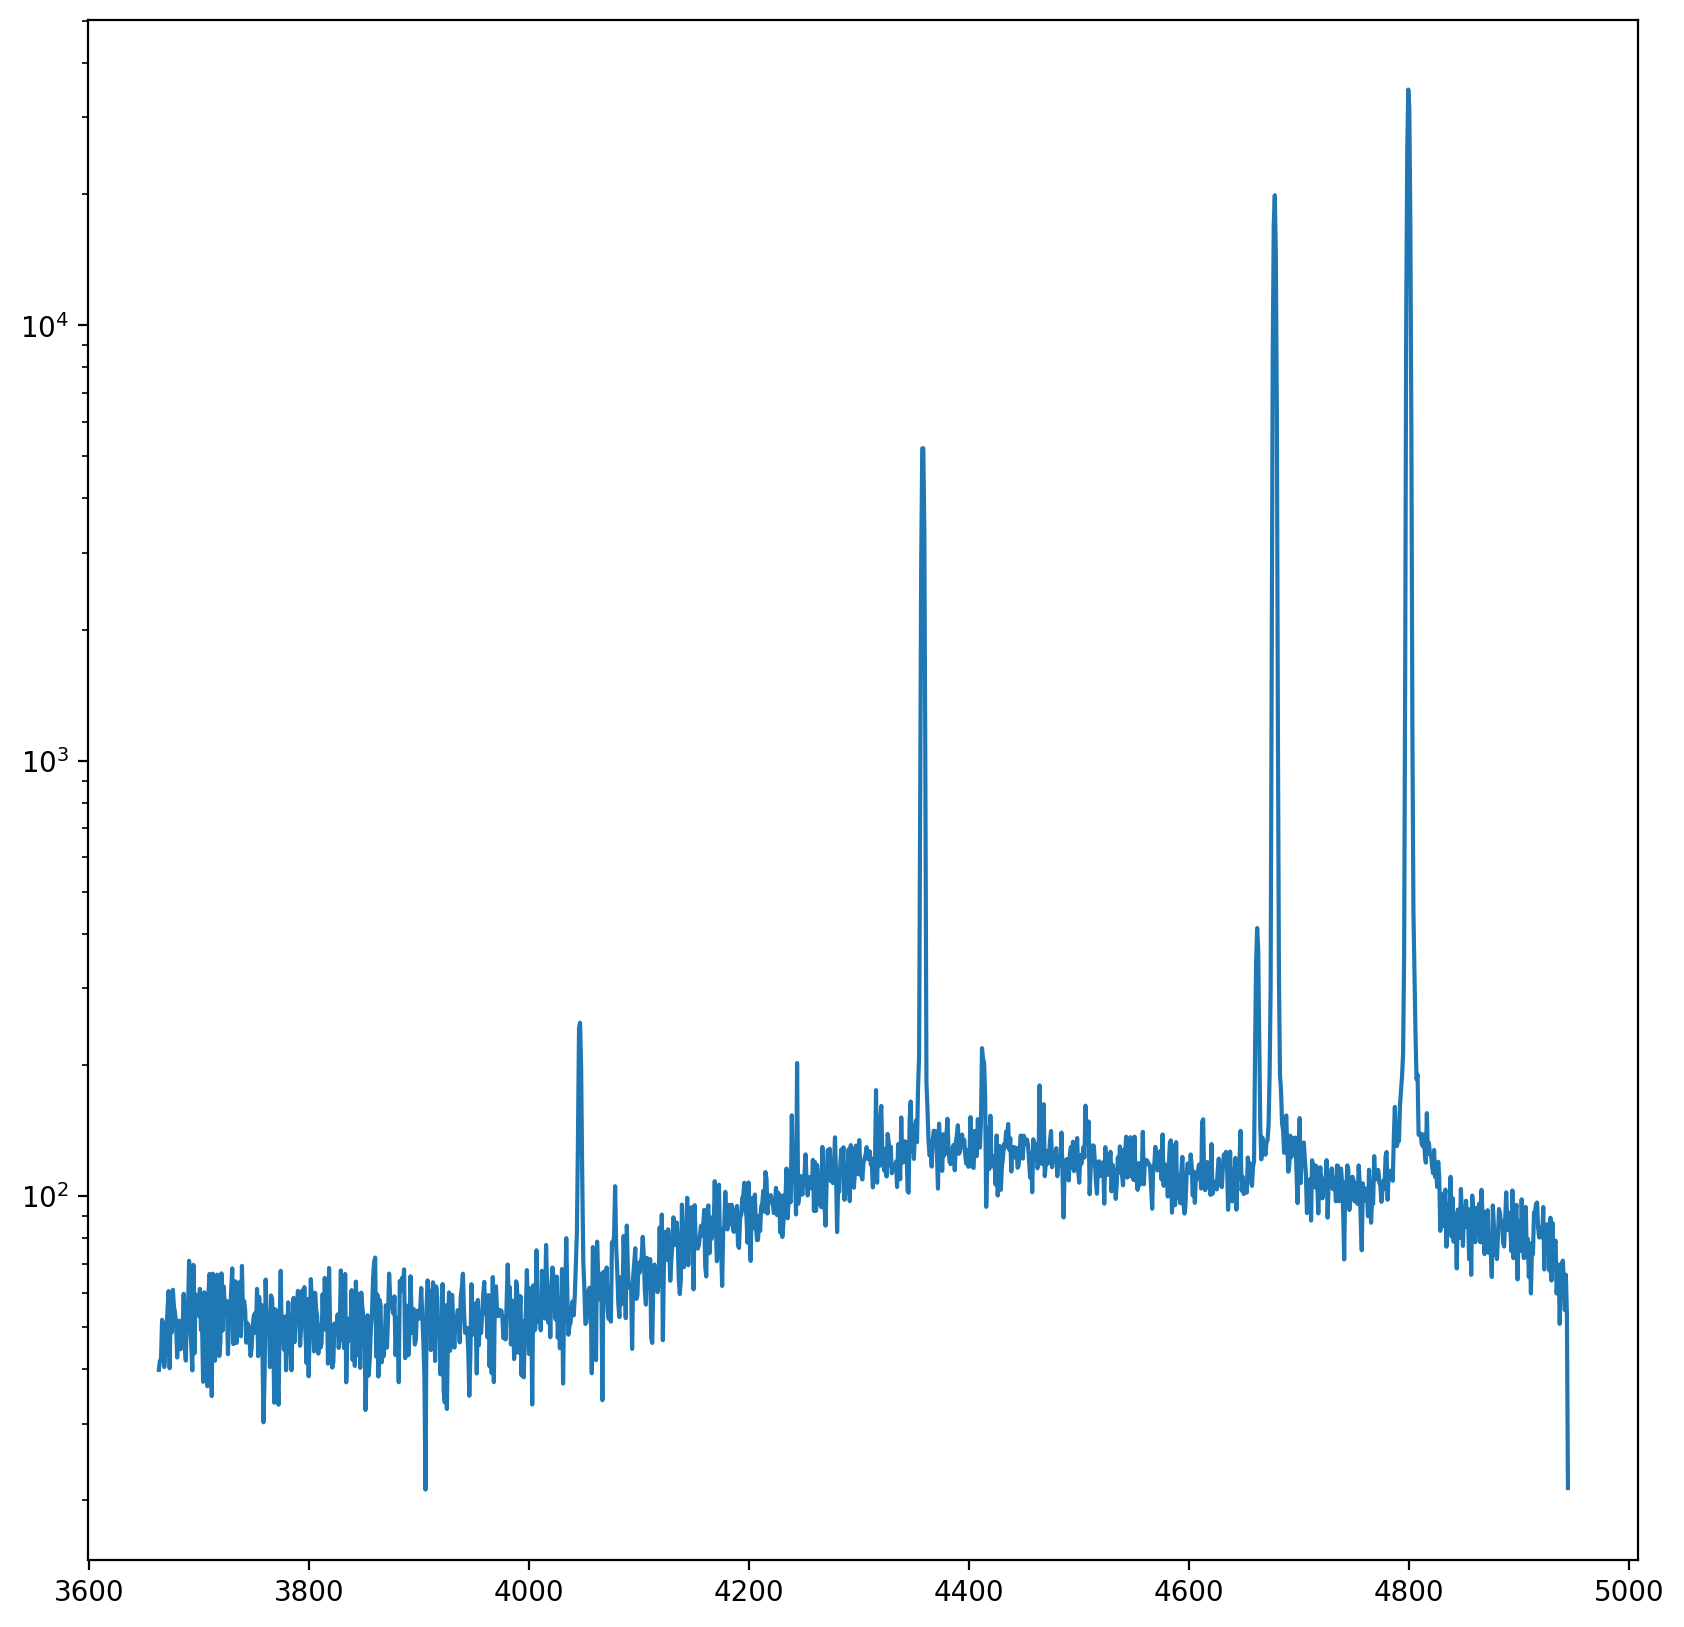

In [104]:
hdul = fits.open(rdpath_600430120)
hdul.info()
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
wave = hdul[2].data[0]
flux = hdul[0].data[0]
# ax.imshow(hdul[0].data, cmap='gray', origin='lower')
# ax.set_xlim(1160, 1200)
# ax.set_xlim(4040, 4090)
# ax.set_ylim(0, 1000)
ax.plot(wave, flux)
ax.set_yscale('log')
# ax.plot(hdul[1].data.T)

hgarnekrcd_f8 = hdul[0].data[-8]

In [72]:
hdul[1].data

array([[5., 5., 5., ..., 5., 5., 5.],
       [5., 5., 5., ..., 5., 5., 5.],
       [5., 5., 5., ..., 5., 5., 5.],
       ...,
       [5., 5., 5., ..., 5., 5., 5.],
       [5., 5., 5., ..., 5., 5., 5.],
       [5., 5., 5., ..., 5., 5., 5.]], shape=(14, 1340), dtype='>f4')

In [110]:
colnames = ["fiber_ID", "target_x", "target_y", "target_ra", "target_dec", "target_rank", "target_class"]
assign_table = Table.read(TESTDIR / "tile_045.assign.txt", names=colnames, format='ascii')
# fiber table columns for kspecdr
assign_table["TYPE"] = "N"
assign_table["TYPE"][assign_table["target_class"] == 9] = "S"
assign_table["TYPE"][np.isin(assign_table["target_class"], [1, 2, 8])] = "P"
assign_table["NAME"] = np.array([f"FIB{i}" for i in assign_table["fiber_ID"]])
assign_table

fiber_ID,target_x,target_y,target_ra,target_dec,target_rank,target_class,TYPE,NAME
int64,float64,float64,float64,float64,float64,int64,str1,str5
1,11.31,72.803,146.815796,8.942098,42.1,9,S,FIB1
2,-37.046,85.957,146.277467,8.80052,42.66,9,S,FIB2
3,-78.99,53.684,145.810547,9.154563,40.51,9,S,FIB3
4,-10.296,56.401,146.574097,9.121504,43.36,9,S,FIB4
5,48.528,35.879,147.233276,9.348256,53.27,9,S,FIB5
6,-28.186,12.837,146.372366,9.60289,16.28,2,P,FIB6
7,77.594,5.478,147.557369,9.683929,52.52,9,S,FIB7
8,4.877,8.094,146.744387,9.655547,49.24,9,S,FIB8
9,-62.682,-7.342,145.986329,9.825863,41.95,9,S,FIB9


In [142]:
tile045_files = list(TESTDIR.glob("tile_045*.fits"))
tile045_files_converted = [CALDIR / f.name.replace("tile_045", "cTile045") for f in tile045_files]

for fpath, fpath_converted in zip(tile045_files, tile045_files_converted):
    write_isoplane_converted_image(fpath, fpath_converted, "OBJECT", fiber_table=assign_table)
    
    make_im(
        fpath_converted.as_posix(),
        cosmic_ray_method="NONE",
        bias_filename=mbias_path.as_posix(),
        use_bias=True,
        verbose=False,
    )
    im_path = CALDIR / (fpath_converted.stem + "_im.fits")
    
    with ImageFile(im_path.as_posix()) as img:
        grating = img.get_header_value("GRATID")
        lambdac = float(img.get_header_value("LAMBDAC"))
        spec_set = f"{grating}_{lambdac/10:.0f}"
    
    tlm_path = CALDIR / ("tlm_" + spec_set + ".fits")
    
    ex_path = CALDIR / (fpath_converted.stem + "_ex.fits")
    make_ex(
        {
            "IMAGE_FILENAME": im_path.as_posix(),
            "EXTRAC_FILENAME": ex_path.as_posix(),
            "TLMAP_FILENAME": tlm_path.as_posix(),
        }
    )

2026-01-30 21:25:53,375 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-01-30 21:25:53,387 | astropy | WARNING | TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
2026-01-30 21:25:53,389 | kspecdr.inst.isoplane | INFO | Adding fiber table with None fibers


2026-01-30 21:25:53,389 | kspecdr.inst.isoplane | WARNING | Fiber table has 14 rows, but n_fibers=None were given. Ignoring n_fibers argument.
2026-01-30 21:25:53,398 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-01-30 21:25:53,414 | kspecdr.preproc.make_im | INFO | Creating IM file from raw data with TDFIO_CREATEBYCOPY functionality...
2026-01-30 21:25:53,414 | kspecdr.preproc.make_im | INFO | Creating IM file from raw file: /data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/260128/calib/cTile045 2026 January 28 14_03_53 1.fits -> /data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/260128/calib/cTile045 2026 January 28 14_03_53 1_im.fits
2026-01-30 21:25:53,422 | kspecdr.preproc.make_im | INFO | Instrument: ISOPLANE, SPECTID: UNKNOWN, CLASS: , BITPIX: 16
2026-01-30 21:25:53,428 | kspecdr.preproc.make_im | INFO | Creating variance HDU for raw file
2026-01-30 21:25:53,460 | kspecdr.preproc.make_im | INFO | Copying fiber table from source file
2026-0

In [152]:
assign_table

fiber_ID,target_x,target_y,target_ra,target_dec,target_rank,target_class,TYPE,NAME
int64,float64,float64,float64,float64,float64,int64,str1,str5
1,11.31,72.803,146.815796,8.942098,42.1,9,S,FIB1
2,-37.046,85.957,146.277467,8.80052,42.66,9,S,FIB2
3,-78.99,53.684,145.810547,9.154563,40.51,9,S,FIB3
4,-10.296,56.401,146.574097,9.121504,43.36,9,S,FIB4
5,48.528,35.879,147.233276,9.348256,53.27,9,S,FIB5
6,-28.186,12.837,146.372366,9.60289,16.28,2,P,FIB6
7,77.594,5.478,147.557369,9.683929,52.52,9,S,FIB7
8,4.877,8.094,146.744387,9.655547,49.24,9,S,FIB8
9,-62.682,-7.342,145.986329,9.825863,41.95,9,S,FIB9


600
4300.0
1800000


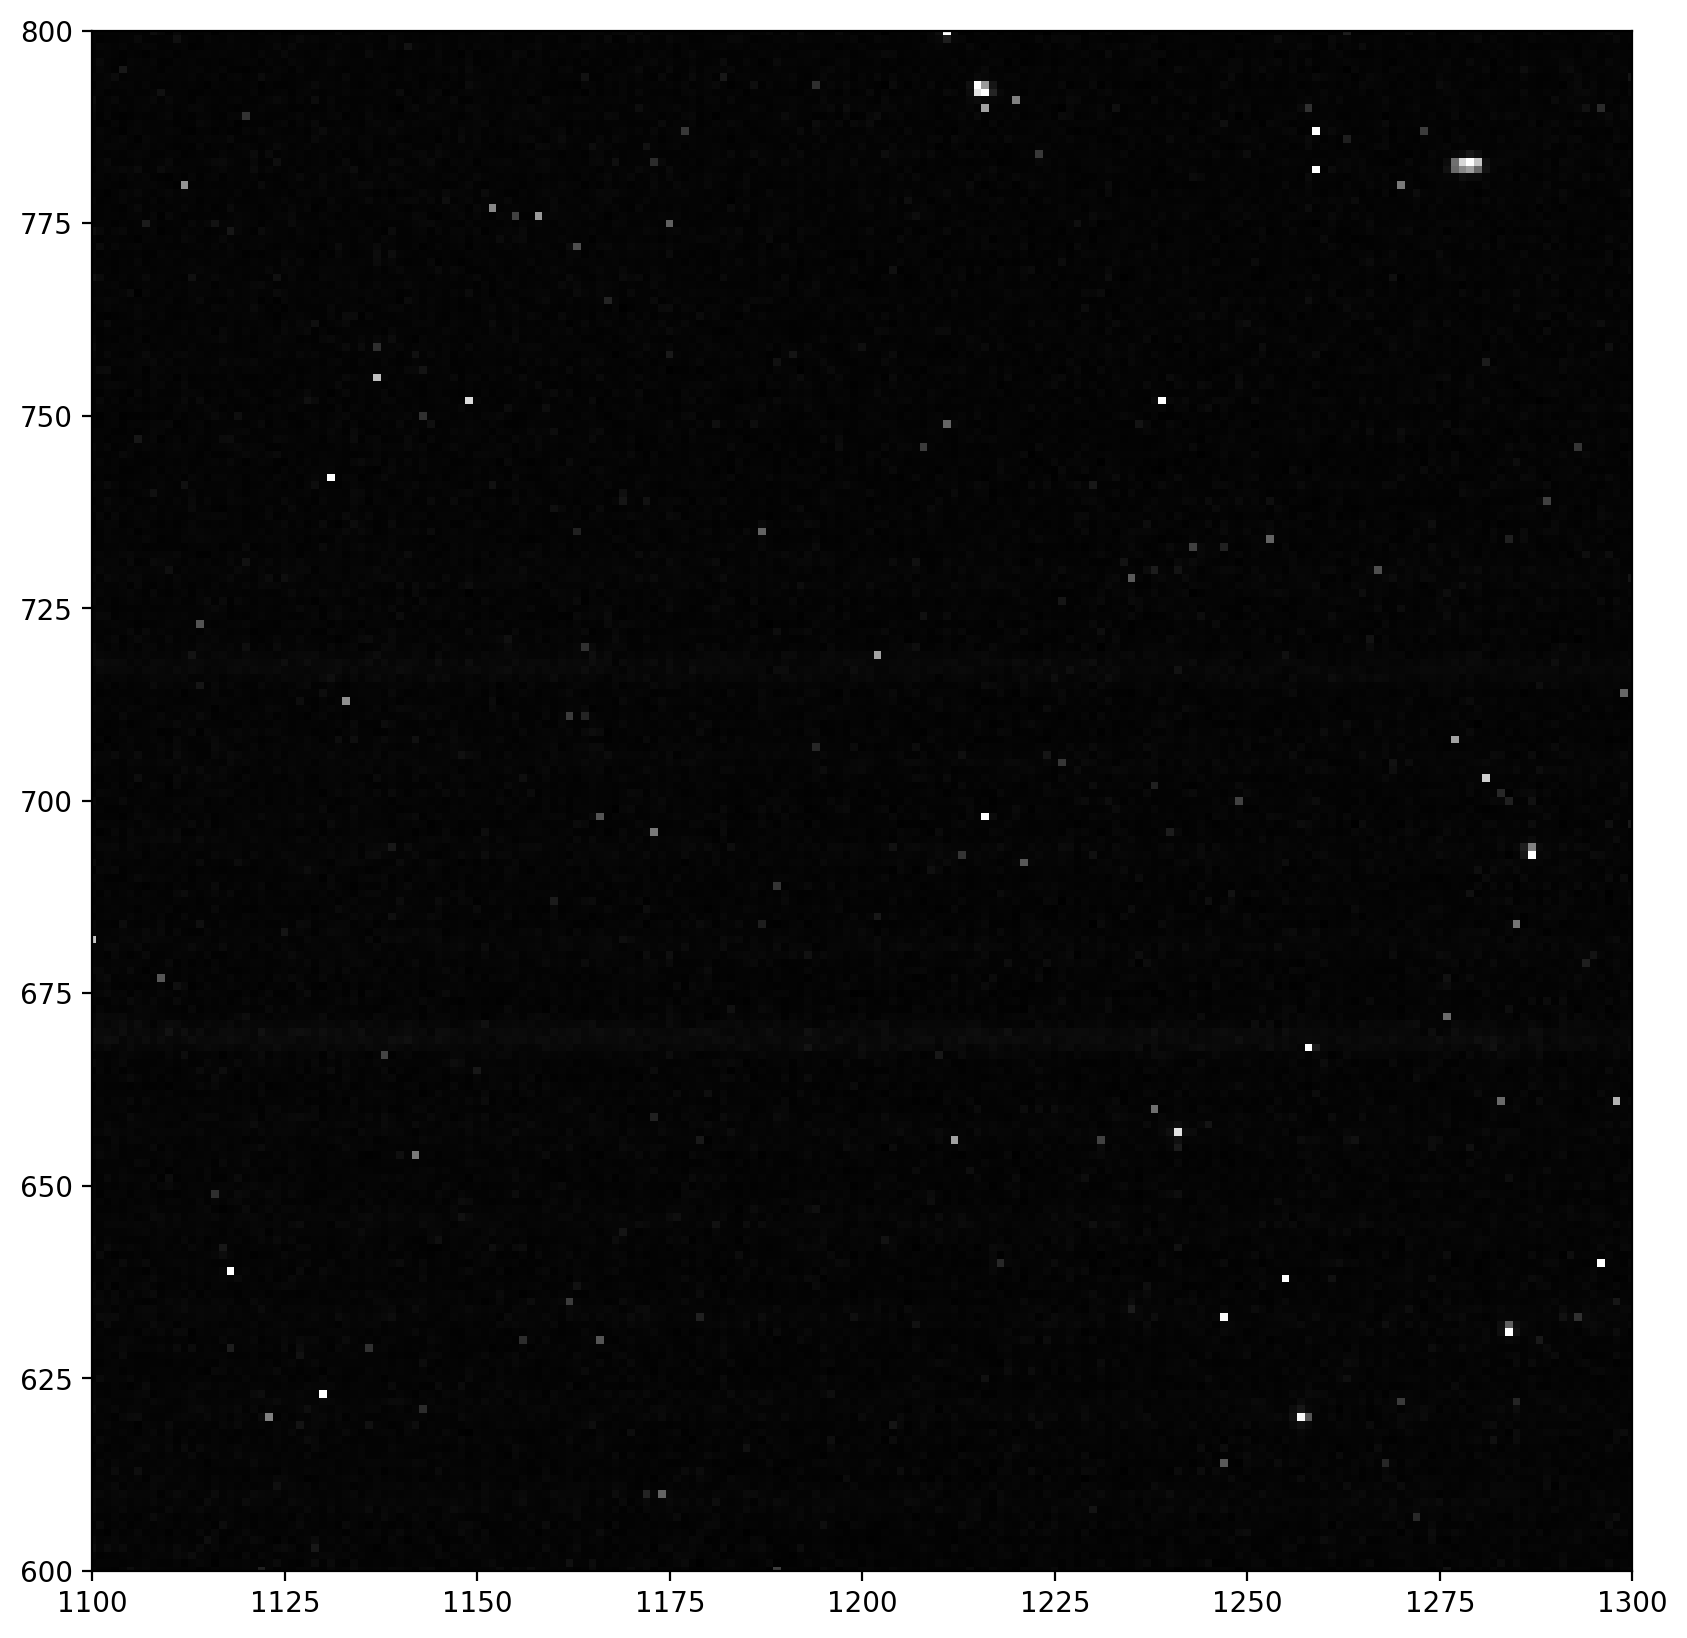

In [168]:
hdul = fits.open(im_path)
# hdul = fits.open(bias_files_converted[0])

print(hdul[0].header["GRATID"])
print(hdul[0].header["LAMBDAC"])
print(hdul[0].header["EXPTIME"])

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.imshow(hdul[0].data, cmap='gray', origin='lower', vmin=0, vmax=1000)
ax.set_xlim(1100, 1300)
ax.set_ylim(600, 800)
plt.show()



600
4300.0
1800000


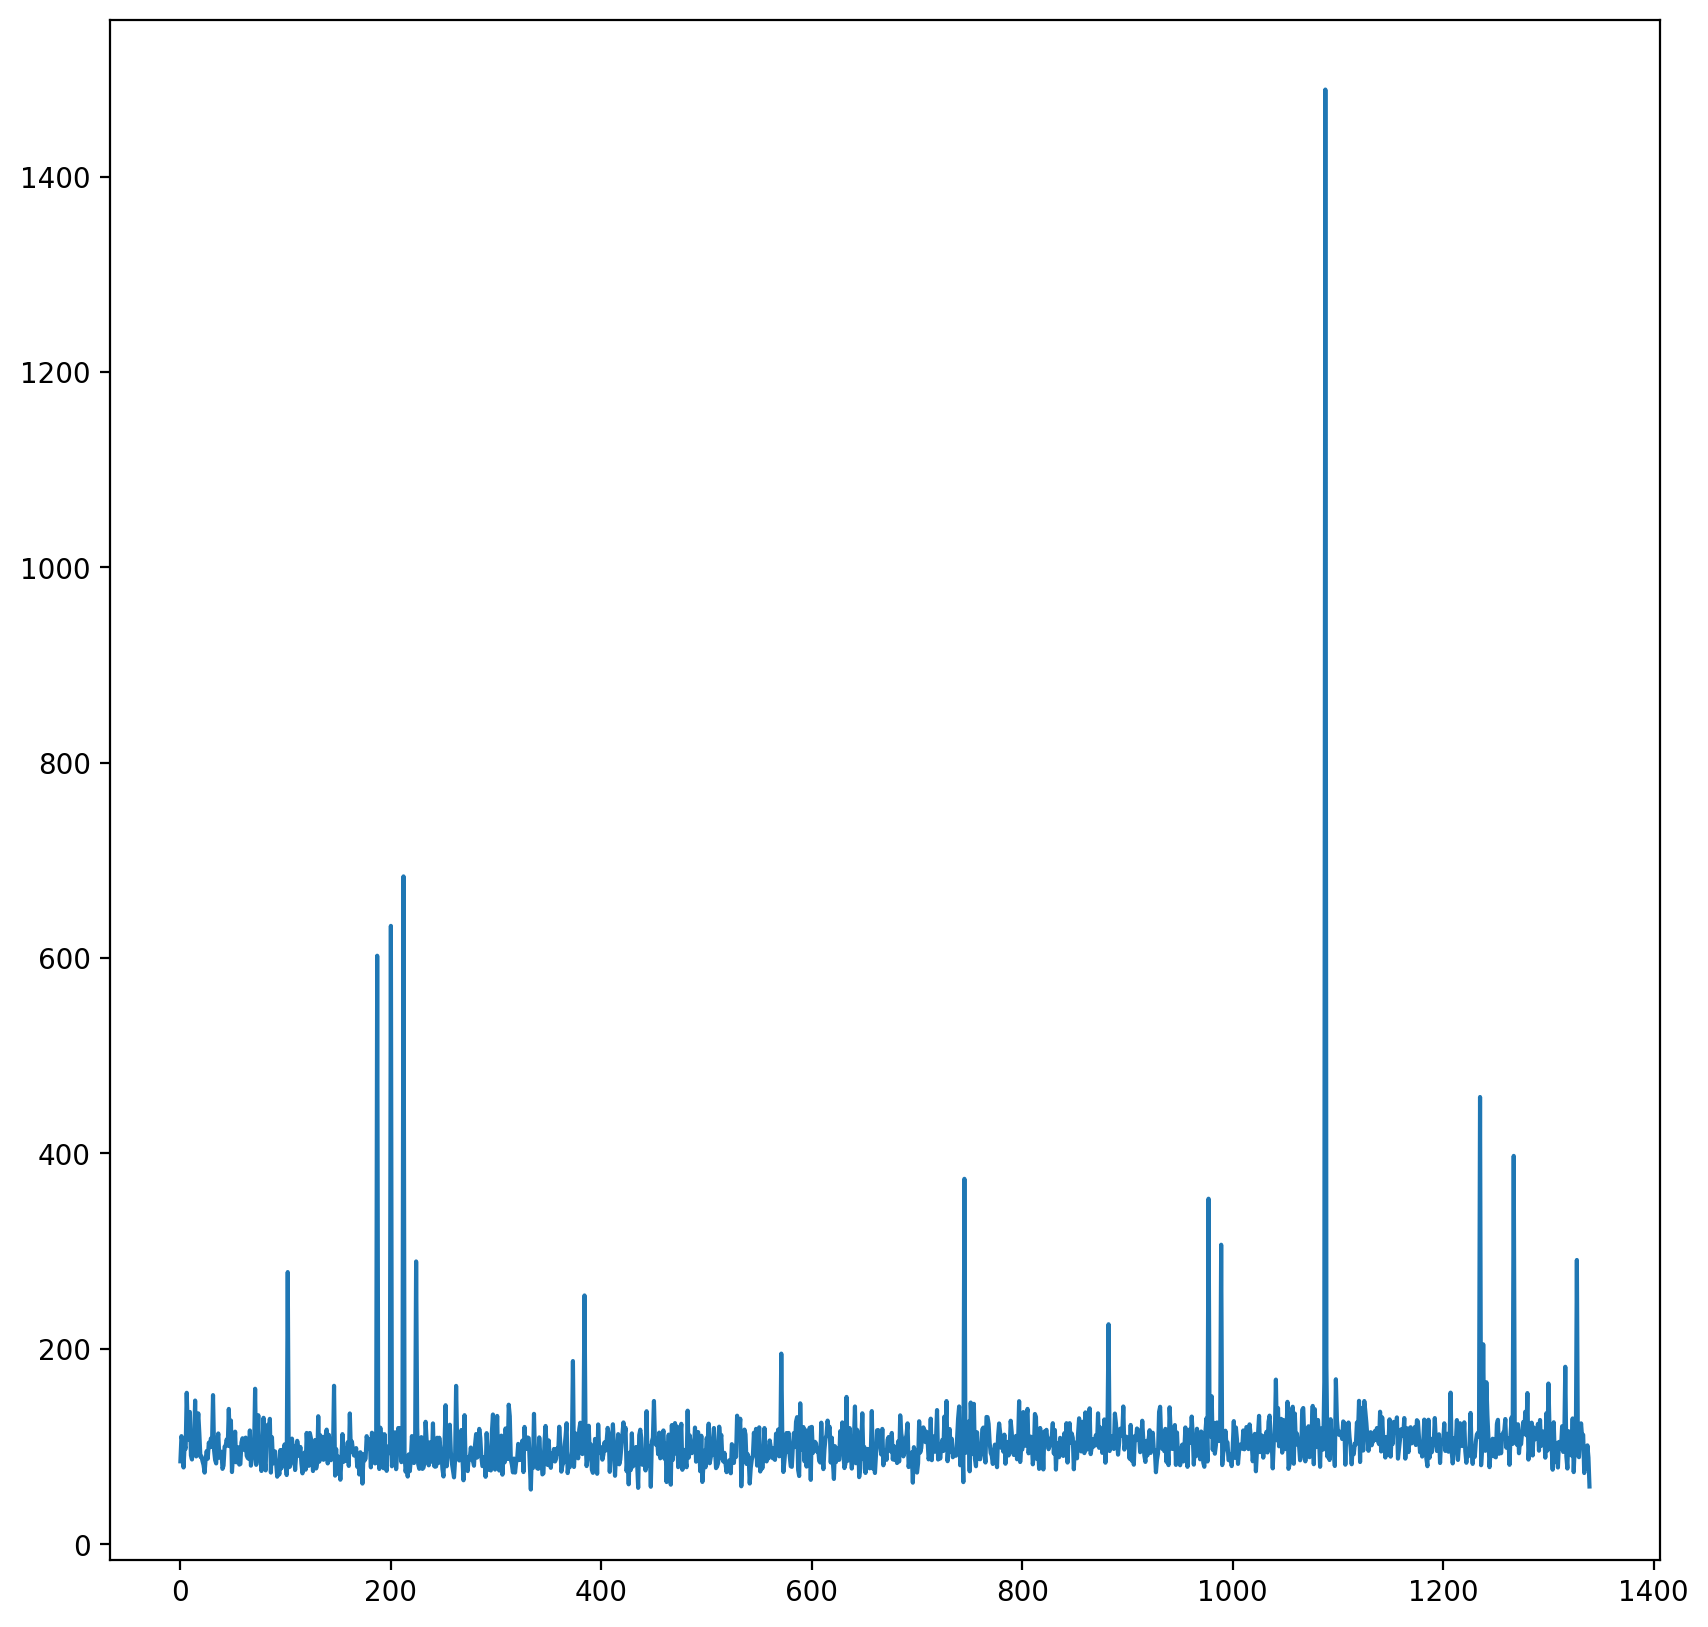

In [154]:
hdul = fits.open(ex_path)

print(hdul[0].header["GRATID"])
print(hdul[0].header["LAMBDAC"])
print(hdul[0].header["EXPTIME"])

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.plot(hdul[0].data[-1])
plt.show()
